# Imports

In [1]:
import pandas as pd
import numpy as np
import os
os.environ['KMP_DUPLICATE_LIB_OK'] = 'True'
export_dir = os.getcwd()
from pathlib import Path
import pickle
from collections import defaultdict
import time
import torch
import torch.nn as nn
import copy
import optuna
import logging
import matplotlib.pyplot as plt
import random
import ipynb
#import wandb
import importlib
from os import path
from collections import Counter


In [2]:
data_name = "Yahoo" ### Can be ML1M, Yahoo, Pinterest
recommender_name = "MLP" ## Can be MLP, VAE
DP_DIR = Path("processed_data", data_name) 
export_dir = Path(os.getcwd())
files_path = Path(export_dir.parent, DP_DIR)
checkpoints_path = Path(export_dir, "checkpoints")
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

In [3]:
output_type_dict = {
    "VAE":"multiple",
    "MLP":"single"
}

num_users_dict = {
    "ML1M":6037,
    "Yahoo":13797, 
    "Pinterest":19155
}

num_items_dict = {
    "ML1M":3381,
    "Yahoo":4604, 
    "Pinterest":9362
}



recommender_path_dict = {
    ("ML1M","VAE"): Path(checkpoints_path, "VAE_ML1M_0.0007_128_10.pt"),
    ("ML1M","MLP"):Path(checkpoints_path, "MLP1_ML1M_0.0076_256_7.pt"),
    
    ("Yahoo","VAE"): Path(checkpoints_path, "VAE_Yahoo_0.0001_128_13.pt"),
    ("Yahoo","MLP"):Path(checkpoints_path, "MLP2_Yahoo_0.0083_128_1.pt"),

    ("Pinterest","VAE"): Path(checkpoints_path, "VAE_Pinterest_0.0002_32_12.pt"),
    ("Pinterest","MLP"):Path(checkpoints_path, "MLP_Pinterest_0.0062_512_21_0.pt")
    
}

hidden_dim_dict = {
    ("ML1M","VAE"): None,
    ("ML1M","MLP"): 32,

    ("Yahoo","VAE"): None,
    ("Yahoo","MLP"):32,
    
    ("Pinterest","VAE"): None,
    ("Pinterest","MLP"):512

}

In [4]:
output_type = output_type_dict[recommender_name] ### Can be single, multiple
num_users = num_users_dict[data_name] 
num_items = num_items_dict[data_name] 
hidden_dim = hidden_dim_dict[(data_name,recommender_name)]
recommender_path = recommender_path_dict[(data_name,recommender_name)]

# Data imports and preprocessing

In [5]:
train_data = pd.read_csv(Path(files_path,f'train_data_{data_name}.csv'), index_col=0)
test_data = pd.read_csv(Path(files_path,f'test_data_{data_name}.csv'), index_col=0)
train_data['user_id'] = train_data.index
test_data['user_id'] = test_data.index
static_test_data = pd.read_csv(Path(files_path,f'static_test_data_{data_name}.csv'), index_col=0)

with open(Path(files_path,f'pop_dict_{data_name}.pkl'), 'rb') as f:
    pop_dict = pickle.load(f)


train_array = train_data.to_numpy()
test_array = test_data.to_numpy()
items_array = np.eye(num_items)
all_items_tensor = torch.Tensor(items_array).to(device)

In [6]:
pop_array = np.zeros(len(pop_dict))
for key, value in pop_dict.items():
    pop_array[key] = value

In [7]:
kw_dict = {'device':device,
          'num_items': num_items,
          'pop_array':pop_array,
          'all_items_tensor':all_items_tensor,
          'static_test_data':static_test_data,
          'items_array':items_array,
          'output_type':output_type,

          'recommender_name':recommender_name}

# Recommenders Architecture

In [8]:
from ipynb.fs.defs.recommenders_architecture import *
importlib.reload(ipynb.fs.defs.recommenders_architecture)
from ipynb.fs.defs.recommenders_architecture import *

In [9]:
VAE_config= {
"enc_dims": [512,128],
"dropout": 0.5,
"anneal_cap": 0.2,
"total_anneal_steps": 200000
}


VAE_config= {
"enc_dims": [512,128],
"dropout": 0.5,
"anneal_cap": 0.2,
"total_anneal_steps": 200000
}

In [10]:
def load_recommender():
    if recommender_name=='MLP':
        recommender = MLP(hidden_dim, **kw_dict)
    elif recommender_name=='VAE':
        recommender = VAE(VAE_config, **kw_dict)

    recommender_checkpoint = torch.load(Path(checkpoints_path, recommender_path), map_location=torch.device('cpu'))
    recommender.load_state_dict(recommender_checkpoint)
    recommender.eval()
    for param in recommender.parameters():
        param.requires_grad= False
    return recommender
    
recommender = load_recommender()

/var/folders/6q/k8kdnnm55nnc37vnzybp6zkc0000gp/T/ipykernel_90513/1950858314.py:7: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  recommender_checkpoint = torch.load(Path(chec

# Help functions

In [11]:
from ipynb.fs.defs.help_functions import *
importlib.reload(ipynb.fs.defs.help_functions)
from ipynb.fs.defs.help_functions import *

In [12]:
def get_user_recommended_item(user_tensor, recommender, **kw):
    all_items_tensor = kw['all_items_tensor']
    num_items = kw['num_items']
    user_res = recommender_run(user_tensor, recommender, all_items_tensor, None, 'vector', **kw)[:num_items]
    user_tensor = user_tensor[:num_items]
    user_catalog = torch.ones_like(user_tensor)-user_tensor
    user_recommenations = torch.mul(user_res, user_catalog)
    # Get the indices of the items sorted by their recommendation score in descending order
    sorted_recommendations = torch.argsort(user_recommenations, descending=True)
    return(sorted_recommendations[0:10])

## Load / create top recommended items dict

In [13]:
## Load / create top recommended items dict

create_dicts = True
if create_dicts:

    ## target and contrastive items for training 
    top1_train, top2_train = {}, {}

    ## target and contrastive items for testing 
    top1_test, top2_test = {}, {}

    ##recommendations for each user in training dataset
    recom_train,recom_test= {}, {}

    for i in range(train_array.shape[0]):
        user_index = train_array[i][-1]
        user_tensor = torch.Tensor(train_array[i][:-1]).to(device)
        recomm_list=get_user_recommended_item(user_tensor, recommender, **kw_dict)

        top1_train[user_index] = int(recomm_list[0])
        ## Sampling for the contrastive item below the target item
        top2_train[user_index]= np.array(recomm_list[1:9].cpu())

    for i in range(test_array.shape[0]):
        user_index = test_array[i][-1]
        user_tensor = torch.Tensor(test_array[i][:-1]).to(device)
        recomm_list=get_user_recommended_item(user_tensor, recommender, **kw_dict)
        ## the target item is the first rank item and contrastive item is rank 7+1=8
        top1_test[user_index] = int(recomm_list[0])
        top2_test[user_index] = np.array(recomm_list[1:9].cpu())
        
    with open(Path(files_path,f'top1_train_{data_name}_{recommender_name}.pkl'), 'wb') as f:
        pickle.dump(top1_train, f)
    with open(Path(files_path,f'top2_train_{data_name}_{recommender_name}.pkl'), 'wb') as f:
        pickle.dump(top2_train, f)
    with open(Path(files_path,f'top1_test_{data_name}_{recommender_name}.pkl'), 'wb') as f:
        pickle.dump(top1_test, f)
    with open(Path(files_path,f'top2_test_{data_name}_{recommender_name}.pkl'), 'wb') as f:
        pickle.dump(top2_test, f)
else:
    with open(Path(files_path,f'top1_train_{data_name}_{recommender_name}.pkl'), 'rb') as f:
        top1_train = pickle.load(f)
    with open(Path(files_path,f'top2_train_{data_name}_{recommender_name}.pkl'), 'rb') as f:
        top2_train = pickle.load(f)
    with open(Path(files_path,f'top1_test_{data_name}_{recommender_name}.pkl'), 'rb') as f:
        top1_test = pickle.load(f)
    with open(Path(files_path,f'top2_test_{data_name}_{recommender_name}.pkl'), 'rb') as f:
        top2_test = pickle.load(f)

# LXR Architecture

In [14]:
def Explainer(user_tensor):
    score_tensor=torch.zeros_like(user_tensor)
    indx=torch.nonzero(user_tensor.squeeze())
    for i in indx:
        idx=i.item()
        score_tensor.squeeze()[idx]=pop_dict[idx].item()
    return score_tensor

In [15]:
# Popularity based similarity
def find_POP_mask(user_tensor,explainer):
    

    pop_x_masked = user_tensor* explainer

    pop_item_sim_dict = {i: pop_x_masked[i].item() for i in range(len(pop_x_masked))}    

    return pop_item_sim_dict

In [16]:

def calculate_pos_neg_k(user_tensor, first_item_id, second_item_id, num_of_bins, explainer):
    user_hist_size = int(torch.sum(user_tensor))
    bins = [0] + [len(x) for x in np.array_split(np.arange(user_hist_size), num_of_bins, axis=0)]

    

    # Helper function to mask items
    def mask_items(user_tensor, sim_items, total_items, device):
        mask = torch.zeros_like(user_tensor, dtype=torch.float32, device=device)
        indices = [item[0] for item in sim_items[:total_items]]
        mask[indices] = 1
        return user_tensor - mask

    # Process each item set (first, second, comparative)
    def process_sim_items(first_sim_items, first_item_id, second_item_id,bins, user_tensor, user_hist_size, recommender, **kw_dict):
       

        first_sorted_sim_items = list(sorted(first_sim_items.items(), key=lambda item: item[1], reverse=True))[:user_hist_size]

        total_items = 0
        for i, bin_size in enumerate(bins):
            total_items += bin_size
            ## masking user profile 
            first_POS_masked = mask_items(user_tensor, first_sorted_sim_items, total_items, device)
            ##index of first item and second item after masking
            First_item_indx = get_index_in_the_list(first_POS_masked, user_tensor, first_item_id, recommender, **kw_dict) + 1
            Second_item_indx = get_index_in_the_list(first_POS_masked, user_tensor, second_item_id, recommender, **kw_dict) + 1
        
            if (First_item_indx > Second_item_indx):
                return total_items, i
            

    
        return None, None

    # Find LXR masks
    pop_sim_items = find_POP_mask(user_tensor, explainer)

    total_items, bin_index=process_sim_items(pop_sim_items, first_item_id, second_item_id, bins, user_tensor, user_hist_size, recommender, **kw_dict)

    return total_items, bin_index, user_hist_size









# LXR training
### Utilizing Optuna for hyperparameter optimization and WandB (Weights and Biases) for experiment tracking and logging.

In [17]:

torch.manual_seed(42)
np.random.seed(42)

num_of_rand_users = 700 # number of users for evaluations
random_rows = np.random.choice(test_array.shape[0], num_of_rand_users, replace=False)
random_sampled_array = test_array[random_rows]
bin_indxs_list=[]
total_items_list=[]
user_hist_size_list=[]
count=0
for j in range(random_sampled_array.shape[0]):
    user_id = random_sampled_array[j][-1]
    user_tensor = torch.Tensor(random_sampled_array[j][:-1]).to(device)
    top1_item_test = top1_test[user_id]
    top2_item_test=np.random.choice(top2_test[user_id])

    first_item_vector = items_array[top1_item_test]
    second_item_vector = items_array[top2_item_test]
    first_items_tensor = torch.Tensor(first_item_vector).to(device)
    second_items_tensor = torch.Tensor(second_item_vector).to(device)
    total_items, bin_indx, user_hist_size= calculate_pos_neg_k(user_tensor, top1_item_test, top2_item_test, 10, Explainer(user_tensor))
    if total_items is not None:
        bin_indxs_list.append(bin_indx)
        count+=1
        total_items_list.append(total_items)
        user_hist_size_list.append(user_hist_size)
        #print('bin_indx:', bin_indx, 'total_items:',total_items)   
with open('New_total_items_POP_VAE_Yahoo.pkl', 'wb') as f:
   pickle.dump(total_items_list, f)

with open('New_bin_indx_POP_VAE_Yahoo.pkl', 'wb') as f:
    pickle.dump(bin_indxs_list, f)

In [18]:
count/700

0.6457142857142857

In [19]:
np.mean(bin_indxs_list)

4.758849557522124

In [20]:
np.mean(total_items_list)

15.380530973451327

In [21]:
np.mean(bin_indxs_list)

4.758849557522124

In [22]:
with open('total_items_POP.pkl', 'wb') as f:
        pickle.dump(total_items_list, f)

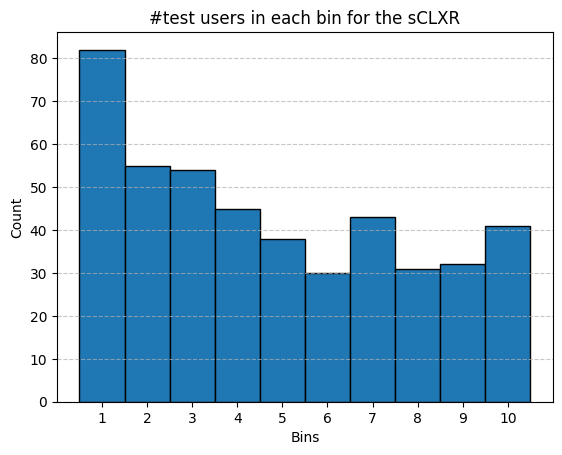

In [23]:
import matplotlib.pyplot as plt

# Example list
data = bin_indxs_list
# Create histogram
plt.hist(data, bins=range(1, 12), edgecolor='black', align='left')  # bins range is 1 to 11 to cover 1-10
plt.title('#test users in each bin for the sCLXR')
plt.xlabel('Bins')
plt.ylabel('Count')
plt.xticks(range(1, 11))  # Ensure all numbers from 1 to 10 are shown
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()